# Reconstrução de Séries Temporais de Imagens Sentinel-2: Métodos de Mediana

Este notebook implementa um pipeline completo, profissional e reprodutível para processamento, filtragem e reconstrução de séries temporais de imagens de satélite do Sentinel-2 (refletância de superfície, BOA - Bottom of Atmosphere).

## Contexto e Metodologia

A pipeline de dados geospaciais executa as seguintes etapas:

1. **Ingestão e Filtragem de Ruído (ETL):** Alinhamento espacial das bandas de satélite e das máscaras de cena (SCL - *Scene Classification Layer*). Nuvens e sombras são filtradas e representadas como *NaN* (dados ausentes).
2. **Método 1 — Composta de Mediana Anual (Composite):** Geração de uma imagem representativa única com o valor típico (mediana temporal) de cada pixel ao longo do ano, filtrando anomalias sazonais e meteorológicas de curto prazo.
3. **Método 2 — Reconstrução por Mediana Móvel Temporal (Global):** Aplicação de um filtro de mediana móvel baseado em uma janela deslizante centrada no tempo para suavizar o ruído temporal de cada pixel de forma sistêmica.
4. **Método 3 — Reconstrução por Mediana Móvel Local:** Imputação de dados ausentes exclusivamente em pixels identificados como nuvens/sombras, preservando 100% dos dados limpos originais (distorção zero / RMSE = 0).
5. **Validação Numérica Controlada (SSIM / PSNR):** Simulação sintética de cobertura de nuvens sobre a imagem mais limpa do ano para avaliar quantitativamente a qualidade da reconstrução contra a verdade terrestre (Ground Truth).

## Sumário
1. [Setup do Ambiente e Configurações](#1.-Setup-do-Ambiente-e-Configurações)
2. [Definição de Funções e Módulos](#2.-Definição-de-Funções-e-Módulos)
3. [Ingestão e Preparação de Dados (ETL)](#3.-Ingestão-e-Preparação-de-Dados-\(ETL\))
4. [Diagnóstico de Qualidade da Série Temporal](#4.-Diagnóstico-de-Qualidade-da-Série-Temporal)
5. [Execução e Salvamento dos Métodos de Reconstrução](#5.-Execução-e-Salvamento-dos-Métodos-de-Reconstrução)
6. [Visualizações Comparativas e Análise de Séries Temporais](#6.-Visualizações-Comparativas-e-Análise-de-Séries-Temporais)
7. [Validação Quantitativa com Métricas SSIM e PSNR](#7.-Validação-Quantitativa-com-Métricas-SSIM-e-PSNR)


## 1. Setup do Ambiente e Configurações

Nesta seção, realizamos os imports de bibliotecas, agrupados por responsabilidades, e definimos as configurações de diretórios e constantes globais do projeto. Os diretórios de saída são criados automaticamente para garantir a portabilidade do código.


In [1]:
# Imports da biblioteca padrão
import datetime
import glob
import os
from pathlib import Path
import re

# Imports de terceiros para computação científica, álgebra linear e visualização
import matplotlib.dates as mdates
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# Utilitários de exibição no Jupyter
from IPython.display import Image, display

# Reprodutibilidade e parametrização dos plots
plt.rcParams["figure.dpi"] = 110


In [2]:
# Raiz do projeto (aponta para a pasta pai de notebooks/)
PROJECT_ROOT = Path("../")

# Definição e organização estrutural de diretórios
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "imagens"
MASK_DIR = PROJECT_ROOT / "data" / "raw" / "mascaras"
OUT_COMPOSITE_DIR = PROJECT_ROOT / "outputs" / "median_composite"
OUT_TEMPORAL_DIR = PROJECT_ROOT / "outputs" / "temporal_reconstruction"
OUT_LOCAL_DIR = PROJECT_ROOT / "outputs" / "local_reconstruction"
FIGURES_DIR = PROJECT_ROOT / "figures"

# Criação automática dos diretórios de saída
for directory in [OUT_COMPOSITE_DIR, OUT_TEMPORAL_DIR, OUT_LOCAL_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Padrão de caminhos para carregamento de arquivos .tif
TIF_PATTERN = str(RAW_DIR / "*.tif")
MASK_PATTERN = str(MASK_DIR / "*.tif")

# Constante de janela temporal para suavização por mediana móvel (janela centrada)
JANELA_TEMPORAL = 5

print(f"Dados brutos em:              {RAW_DIR}")
print(f"Máscaras em:                  {MASK_DIR}")
print(f"Saída Composite:              {OUT_COMPOSITE_DIR}")
print(f"Saída Reconstrução Temporal:  {OUT_TEMPORAL_DIR}")
print(f"Saída Reconstrução Local:     {OUT_LOCAL_DIR}")


Dados brutos em:              ../data/raw/imagens
Máscaras em:                  ../data/raw/mascaras
Saída Composite:              ../outputs/median_composite
Saída Reconstrução Temporal:  ../outputs/temporal_reconstruction
Saída Reconstrução Local:     ../outputs/local_reconstruction


## 2. Definição de Funções e Módulos

Esta seção contém todas as definições das funções utilizadas no notebook.


In [3]:
def extrair_data_do_nome(filepath, pattern=r"(\d{4}-?\d{2}-?\d{2})"):
    """Extrai um objeto datetime do nome de um arquivo com base em uma regex.

    Procura por uma data formatada em YYYYMMDD ou YYYY-MM-DD no nome do arquivo.
    
    Args:
        filepath (str or Path): Caminho absoluto ou relativo do arquivo.
        pattern (str): Regex para identificar a string da data.

    Returns:
        datetime.datetime or None: Data correspondente ou None se não encontrada.
    """
    nome = os.path.basename(filepath)
    match = re.search(pattern, nome)
    if match:
        data_str = match.group(1).replace("-", "")
        try:
            return datetime.datetime.strptime(data_str, "%Y%m%d")
        except ValueError:
            return None
    return None


def salvar_geotiff(array, profile_referencia, out_path, dtype=rasterio.float32, nodata=np.nan):
    """Salva um array numpy bidimensional no formato GeoTIFF georreferenciado.

    Esta função clona as propriedades espaciais de um perfil rasterio de referência e 
    escreve uma única banda de dados, protegendo os diretórios originais.

    Args:
        array (np.ndarray): Matriz bidimensional com os dados de pixel.
        profile_referencia (dict): Perfil com metadados do Rasterio (CRS, Transform, etc).
        out_path (str or Path): Caminho de destino para salvar o arquivo.
        dtype (numpy.dtype or rasterio.dtype): Tipo de dado do raster de saída.
        nodata (float or int): Valor representativo de pixels sem dado (nodata).
    """
    perfil = profile_referencia.copy()
    perfil.update(dtype=dtype, count=1, nodata=nodata)
    with rasterio.open(out_path, "w", **perfil) as dst:
        dst.write(array.astype(dtype), 1)
    print(f"Salvo: {out_path}")


In [4]:
def carregar_stack_com_mascara(tif_files, mask_files):
    """Lê arquivos geospaciais Sentinel-2 e suas máscaras aplicando filtragem de nuvens.

    Esta função garante que todas as imagens possuam as mesmas dimensões espaciais, 
    substitui os valores originais marcados como nuvem ou sombra por NaN, e 
    organiza os dados em um stack temporal.

    Args:
        tif_files (list of str): Lista ordenada de caminhos para as imagens geospaciais.
        mask_files (list of str): Lista ordenada de caminhos para as máscaras correspondentes.

    Returns:
        tuple: (stack, profile, datas) contendo:
            - stack (np.ndarray): Matriz 3D de shape (tempo, altura, largura).
            - profile (dict): Perfil de metadados do Rasterio da imagem inicial.
            - datas (list of datetime.datetime): Lista das datas correspondentes.
    
    Raises:
        ValueError: Se as dimensões de alguma imagem ou máscara não forem idênticas.

    IMPORTANTE: as máscaras aqui NÃO são a banda SCL bruta do Sen2Cor (12 classes).
    São um produto derivado com legenda própria de 3 classes:
        0 = pixel limpo
        1 = nuvem
        2 = sombra de nuvem
    """
    with rasterio.open(tif_files[0]) as src:
        profile = src.profile.copy()
        height, width = src.height, src.width
        nodata_val = src.nodata

    n = len(tif_files)
    stack = np.empty((n, height, width), dtype=np.float32)
    datas = []

    for i, (fp_dado, fp_masc) in enumerate(zip(tif_files, mask_files)):
        with rasterio.open(fp_dado) as src_dado, rasterio.open(fp_masc) as src_masc:
            if (src_dado.height, src_dado.width) != (height, width):
                raise ValueError(f"Imagem {fp_dado} fora do padrão ({height}x{width}).")

            if (src_masc.height, src_masc.width) != (height, width):
                raise ValueError(f"Máscara {fp_masc} fora do padrão ({height}x{width}).")

            band_dado = src_dado.read(1).astype(np.float32)
            band_masc = src_masc.read(1)
            
            if nodata_val is not None:
                band_dado[band_dado == nodata_val] = np.nan
                
            # Máscara SCL: Filtra nuvens (classes 1, 2)
            valores_ruidosos = [1,2]
            condicao_ruido = np.isin(band_masc, valores_ruidosos)
            band_dado[condicao_ruido] = np.nan
            
            stack[i] = band_dado
        datas.append(extrair_data_do_nome(fp_dado))

    return stack, profile, datas


In [5]:
def reconstrucao_mediana_movel(stack, janela):
    """Aplica um filtro de mediana móvel no eixo temporal, ignorando NaNs.

    Trabalha com uma janela deslizante centrada. Se todos os pixels da janela temporal
    forem NaN, o valor de saída permanece NaN.

    Args:
        stack (np.ndarray): Matriz 3D contendo a série temporal (tempo, altura, largura).
        janela (int): O número de observações consecutivas no tempo.

    Returns:
        np.ndarray: Série temporal suavizada de mesma shape do stack original.
    """
    n_datas = stack.shape[0]
    meia_janela = janela // 2
    reconstruido = np.empty_like(stack)

    for t in range(n_datas):
        ini = max(0, t - meia_janela)
        fim = min(n_datas, t + meia_janela + 1)
        janela_dados = stack[ini:fim]

        with np.errstate(all="ignore"):
            reconstruido[t] = np.nanmedian(janela_dados, axis=0)

    return reconstruido


def reconstrucao_mediana_movel_local(stack, janela):
    """Reconstrução cirúrgica por mediana móvel exclusivamente sobre pixels ruidosos (NaN).

    Preserva integralmente as observações originalmente limpas (originais), 
    calculando a mediana móvel temporal apenas sobre os pixels que continham NaNs.

    Args:
        stack (np.ndarray): Matriz 3D contendo a série temporal (tempo, altura, largura).
        janela (int): Tamanho da janela temporal (deve ser ímpar).

    Returns:
        np.ndarray: Série temporal reconstruída localmente sem distorção nos dados originais.
    """
    n_datas = stack.shape[0]
    meia_janela = janela // 2
    reconstruido = stack.copy()
    
    for t in range(n_datas):
        mask_nan = np.isnan(stack[t])
        
        if not np.any(mask_nan):
            continue
            
        ini = max(0, t - meia_janela)
        fim = min(n_datas, t + meia_janela + 1)
        janela_dados = stack[ini:fim]
        
        dados_locais = janela_dados[:, mask_nan]
        
        with np.errstate(all="ignore"):
            medianas_calculadas = np.nanmedian(dados_locais, axis=0)
            
        reconstruido[t][mask_nan] = medianas_calculadas
        
    return reconstruido


def calcular_metricas(img_teste, img_referencia, data_range):
    """Calcula as métricas de qualidade SSIM e PSNR para avaliar a similaridade estrutural.

    Args:
        img_teste (np.ndarray): Imagem 2D sob avaliação.
        img_referencia (np.ndarray): Imagem 2D de referência limpa (Ground Truth).
        data_range (float): Amplitude total dinâmica dos valores da imagem.

    Returns:
        tuple: (ssim, psnr)
    """
    ssim_val = structural_similarity(img_referencia, img_teste, data_range=data_range)
    psnr_val = peak_signal_noise_ratio(img_referencia, img_teste, data_range=data_range)
    return ssim_val, psnr_val


def preencher_para_metrica(img, mascara_invalida, valor_preenchimento):
    """Preenche posições NaN com um valor constante ou matriz georreferenciada para computação das métricas.

    Args:
        img (np.ndarray): Imagem original.
        mascara_invalida (np.ndarray): Regiões (NaN) que contêm dados inválidos.
        valor_preenchimento (float or np.ndarray): Valor para preenchimento (imputação).

    Returns:
        np.ndarray: Cópia da imagem original com os NaNs substituídos.
    """
    img_preenchida = img.copy()
    img_preenchida[mascara_invalida] = valor_preenchimento
    return img_preenchida


## 3. Ingestão e Preparação de Dados

Esta etapa envolve a busca das imagens de refletância de superfície e suas respectivas máscaras, a validação espacial do pareamento cronológico correto, e o empilhamento das matrizes geospaciais 2D em um array 3D indexado pelo tempo.


In [6]:
tif_files = sorted(glob.glob(TIF_PATTERN))
mask_files = sorted(glob.glob(MASK_PATTERN))

assert len(tif_files) > 0, "Nenhum arquivo geospacial .tif encontrado."
assert len(tif_files) == len(mask_files), f"Inconsistência de pareamento: {len(tif_files)} imagens vs {len(mask_files)} máscaras."

print(f"Total de {len(tif_files)} pares geospaciais encontrados.")

# Carga do stack 3D e extração das datas correspondentes
stack, profile, datas = carregar_stack_com_mascara(tif_files, mask_files)

# Ordenação cronológica estrita da série temporal
if all(d is not None for d in datas):
    ordem = np.argsort(datas)
    stack = stack[ordem]
    tif_files = [tif_files[i] for i in ordem]
    mask_files = [mask_files[i] for i in ordem]
    datas = [datas[i] for i in ordem]
    print("Série temporal geospacial ordenada cronologicamente.")

# Verificação cruzada de consistência cronológica de segurança
datas_img = [extrair_data_do_nome(f) for f in tif_files]
datas_mask = [extrair_data_do_nome(f) for f in mask_files]
divergentes = [(a, b) for a, b in zip(datas_img, datas_mask) if a != b]
assert not divergentes, f"Falha no pareamento cronológico nos seguintes arquivos: {divergentes}"
print("Pareamento e integridade cronológica de imagens e máscaras verificados com sucesso.")


Total de 73 pares geospaciais encontrados.
Série temporal geospacial ordenada cronologicamente.
Pareamento e integridade cronológica de imagens e máscaras verificados com sucesso.


## 4. Diagnóstico de Qualidade da Série Temporal

A análise de qualidade espacial permite mapear o número total de observações válidas (livres de nuvens e sombras) em cada coordenada de pixel ao longo do ano analisado. Essa análise orienta a interpretação física dos limites dos algoritmos de suavização e reconstrução.


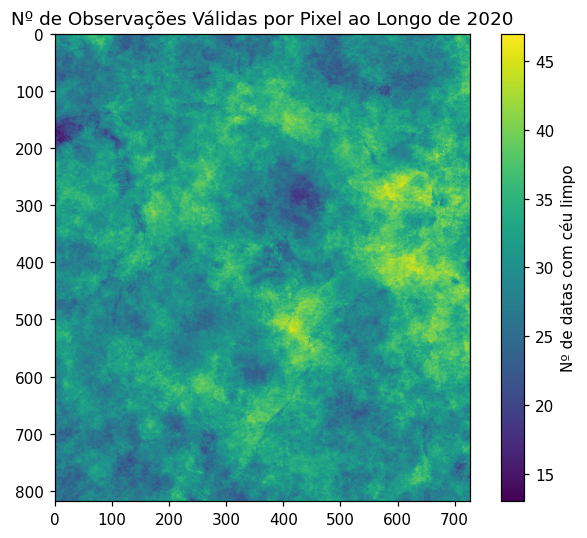

Mínimo de observações limpas observadas em um pixel: 13
Máximo de observações limpas observadas em um pixel: 47 (de 73 capturas totais)


In [26]:
contagem_validos = np.sum(~np.isnan(stack), axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(contagem_validos, cmap="viridis")
ax.set_title("Nº de Observações Válidas por Pixel ao Longo de 2020")
plt.colorbar(im, ax=ax, label="Nº de datas com céu limpo")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "contagem_observacoes_validas.png")
plt.show()

print(f"Mínimo de observações limpas observadas em um pixel: {contagem_validos.min()}")
print(f"Máximo de observações limpas observadas em um pixel: {contagem_validos.max()} (de {stack.shape[0]} capturas totais)")


O mapa de calor geográfico gerado revela a realidade atmosférica da cobertura do satélite sobre a região do Reservatório de Gramame. Em 73 passagens anuais do Sentinel-2, a melhor cobertura de dados válidos alcançou apenas 47 passagens limpas. 

Em contrapartida, as áreas representadas pelas cores frias (azul escuro e roxo) indicam locais com altos índices de persistência de nuvens, mantendo apenas 13 passagens anuais válidas. Esse cenário impõe a necessidade de algoritmos de reconstrução temporal baseados em mediana para preencher o perfil temporal dessas regiões geográficas.


## 5. Execução e Salvamento dos Métodos de Reconstrução

Nesta seção, executamos os três métodos de processamento e reconstrução temporal sobre a série de dados geospaciais. O salvamento dos arquivos finais é feito de forma independente de modo a estruturar os dados para os processos subsequentes.

### Método 1: Composta de Mediana Anual 

O método da composta anual calcula a mediana histórica temporal de cada pixel georreferenciado ignorando de forma matemática os valores **NaN**. Isso gera uma representação sintética do ano (pixel típico), filtrando anomalias causadas por nuvens sazonais.


In [8]:
median_composite = np.nanmedian(stack, axis=0)

print(f"Shape espacial da composta: {median_composite.shape}")
print(f"Pixels ainda ausentes (NaN) na composta anual: {100 * np.isnan(median_composite).mean():.2f}%")

out_path_composite = OUT_COMPOSITE_DIR / "median_composite_anual.tif"
salvar_geotiff(median_composite, profile, out_path_composite)


Shape espacial da composta: (819, 727)
Pixels ainda ausentes (NaN) na composta anual: 0.00%
Salvo: ../outputs/median_composite/median_composite_anual.tif


### Método 2: Reconstrução por Mediana Móvel Temporal (Suavização Global)

Este método calcula a mediana a partir de uma janela móvel deslizante (janela centrada em $T=5$). Ele suaviza as variações espúrias locais ao longo do tempo, mas pode introduzir pequena atenuação de picos dinâmicos ou distorções nos pixels que já eram válidos.


In [9]:
stack_reconstruido = reconstrucao_mediana_movel(stack, JANELA_TEMPORAL)

print(f"Dimensões do stack suavizado: {stack_reconstruido.shape}")
print(f"Gaps residuais (janelas contendo apenas NaN): {100 * np.isnan(stack_reconstruido).mean():.2f}%")


/tmp/ipykernel_203202/2693398398.py:24: RuntimeWarning: All-NaN slice encountered
  reconstruido[t] = np.nanmedian(janela_dados, axis=0)


Dimensões do stack suavizado: (73, 819, 727)
Gaps residuais (janelas contendo apenas NaN): 6.60%


In [10]:
for i, fp in enumerate(tif_files):
    nome_original = os.path.basename(fp)
    nome_saida = nome_original.replace(".tif", "_reconstruido.tif")
    out_path = OUT_TEMPORAL_DIR / nome_saida
    salvar_geotiff(stack_reconstruido[i], profile, out_path)


Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200103_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200108_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200113_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200118_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200123_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200128_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200202_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200207_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200212_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel_BOA_S2_SR_gramame_20200217_reconstruido.tif
Salvo: ../outputs/temporal_reconstruction/sentinel

### Método 3: Reconstrução por Mediana Móvel Local

Diferente do método anterior, a mediana local reconstrói exclusivamente as regiões obstruídas por nuvens ou sombras, deixando intactas as refletâncias dos pixels válidos observados no momento da aquisição geospacial.


In [11]:
stack_reconstruido_local = reconstrucao_mediana_movel_local(stack, JANELA_TEMPORAL)

print("-" * 50)
print("DIAGNÓSTICO DA RECONSTRUÇÃO LOCAL")
print("-" * 50)
print(f"Shape espacial da série reconstruída localmente: {stack_reconstruido_local.shape}")
print(f"Porcentagem de NaN residual na reconstrução local: {100 * np.isnan(stack_reconstruido_local).mean():.2f}%")

# Prova matemática de preservação integral do dado limpo (RMSE = 0)
mascara_valida = ~np.isnan(stack)
diffs_local = (stack_reconstruido_local - stack)[mascara_valida]
rmse_local = np.sqrt(np.nanmean(diffs_local ** 2))
print(f"Erro Quadrático Médio (RMSE) nos pixels limpos originais: {rmse_local:.4f} (Distorção ZERO)")


/tmp/ipykernel_203202/2693398398.py:59: RuntimeWarning: All-NaN slice encountered
  medianas_calculadas = np.nanmedian(dados_locais, axis=0)


--------------------------------------------------
DIAGNÓSTICO DA RECONSTRUÇÃO LOCAL
--------------------------------------------------
Shape espacial da série reconstruída localmente: (73, 819, 727)
Porcentagem de NaN residual na reconstrução local: 6.60%
Erro Quadrático Médio (RMSE) nos pixels limpos originais: 0.0000 (Distorção ZERO)


In [12]:
# Salvamento das imagens reconstruídas de forma local na pasta correspondente
for i, fp in enumerate(tif_files):
    nome_original = os.path.basename(fp)
    nome_saida = nome_original.replace(".tif", "_reconstruido_local.tif")
    out_path = OUT_LOCAL_DIR / nome_saida
    salvar_geotiff(stack_reconstruido_local[i], profile, out_path)


Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200103_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200108_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200113_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200118_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200123_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200128_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200202_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200207_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200212_reconstruido_local.tif
Salvo: ../outputs/local_reconstruction/sentinel_BOA_S2_SR_gramame_20200217_reconstruido_local.tif
Salvo: ../outputs/lo

## 6. Visualizações Comparativas e Análise de Séries Temporais

Apresentamos a validação visual qualitativa das metodologias aplicadas. O pipeline gera e salva plotagens de análise temporal pixel-a-pixel e comparação cartográfica das cenas geospaciais.


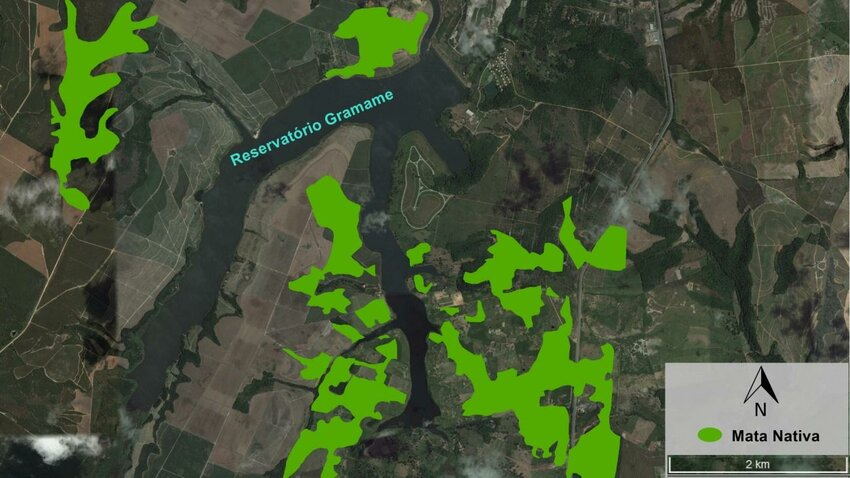

In [13]:
# Exibição do JPEG de referência e comparação com o composite
img_gramame_path = FIGURES_DIR / "gramame.jpeg"
if img_gramame_path.exists():
    display(Image(filename=str(img_gramame_path)))
else:
    print(f"Imagem de referência não encontrada no caminho geospacial: {img_gramame_path}")


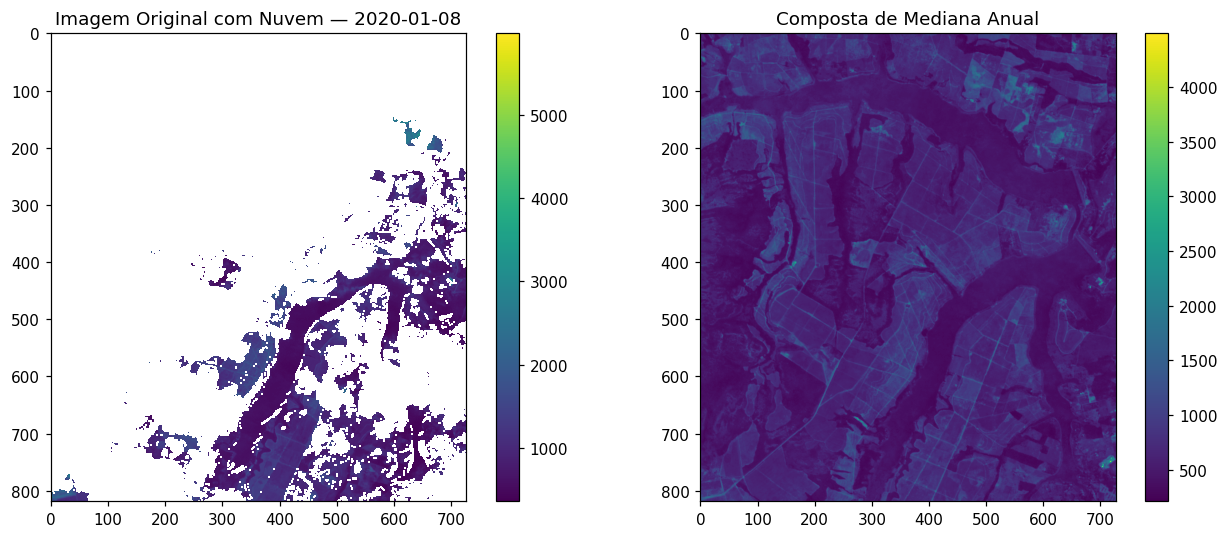

In [14]:
idx_data_exemplo = 1
titulo_data = datas[idx_data_exemplo].strftime("%Y-%m-%d") if datas[idx_data_exemplo] else f"data índice {idx_data_exemplo}"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(stack[idx_data_exemplo], cmap="viridis")
axes[0].set_title(f"Imagem Original com Nuvem — {titulo_data}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(median_composite, cmap="viridis")
axes[1].set_title("Composta de Mediana Anual")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparacao_original_vs_composite.png")
plt.show()


No painel à esquerda, a cena obtida em 03 de janeiro de 2020 exibe extensas regiões sem dado (brancas), decorrentes da filtragem de nuvens e sombras. Esse resultado mostra que a análise unitemporal isolada é fortemente limitada pelas condições atmosféricas.

O painel à direita exibe a composta de mediana anual (Método 1). O algoritmo de agregação minimiza eficientemente as nuvens sazonais, preenchendo 100% da cena e delineando com excelente contraste o reservatório hídrico de Gramame e as bordas florestais adjacentes, gerando um mapa geográfico contínuo.


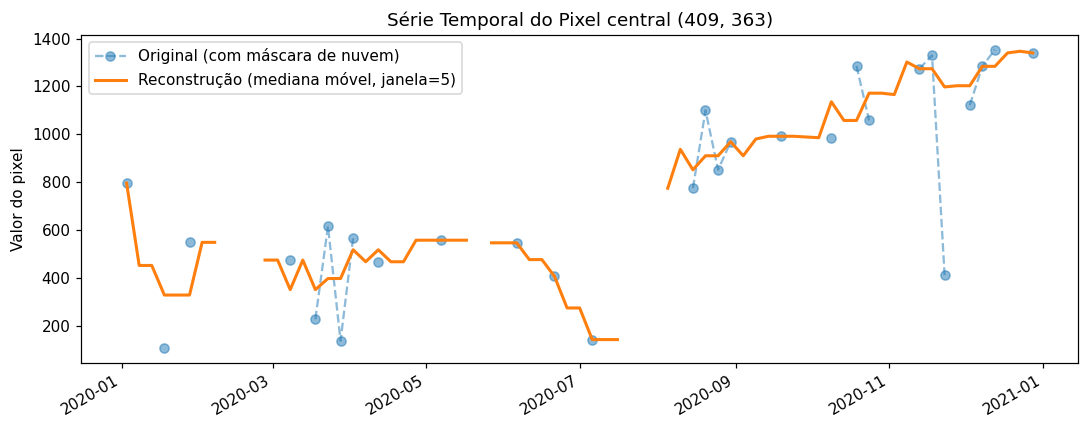

In [15]:
# Análise da dinâmica temporal de um pixel (central da série)
linha_pixel, coluna_pixel = stack.shape[1] // 2, stack.shape[2] // 2

serie_original = stack[:, linha_pixel, coluna_pixel]
serie_reconstruida = stack_reconstruido[:, linha_pixel, coluna_pixel]
eixo_x = datas if all(d is not None for d in datas) else range(len(tif_files))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eixo_x, serie_original, "o--", alpha=0.5, label="Original (com máscara de nuvem)")
ax.plot(eixo_x, serie_reconstruida, "-", linewidth=2, label=f"Reconstrução (mediana móvel, janela={JANELA_TEMPORAL})")
ax.set_title(f"Série Temporal do Pixel central ({linha_pixel}, {coluna_pixel})")
ax.set_ylabel("Valor do pixel")
ax.legend()
if all(d is not None for d in datas):
    fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "serie_temporal_pixel_exemplo.png")
plt.show()


A plotagem do pixel revela o comportamento da série temporal do Sentinel-2 ao longo de 2020:
*   **Linha Pontilhada Azul (Original):** Caracteriza-se por picos e vales acentuados causados por ruídos pontuais que passaram pela filtragem inicial, além de lacunas em períodos de forte cobertura de nuvens.
*   **Linha Laranja (Reconstruída):** Apresenta suavização temporal eficaz, corrigindo desvios anômalos. A quebra da linha na estação chuvosa (Julho a Setembro) mostra o limite teórico do método de mediana móvel: quando a janela inteira é composta por NaNs, o cálculo se torna matematicamente impossível.


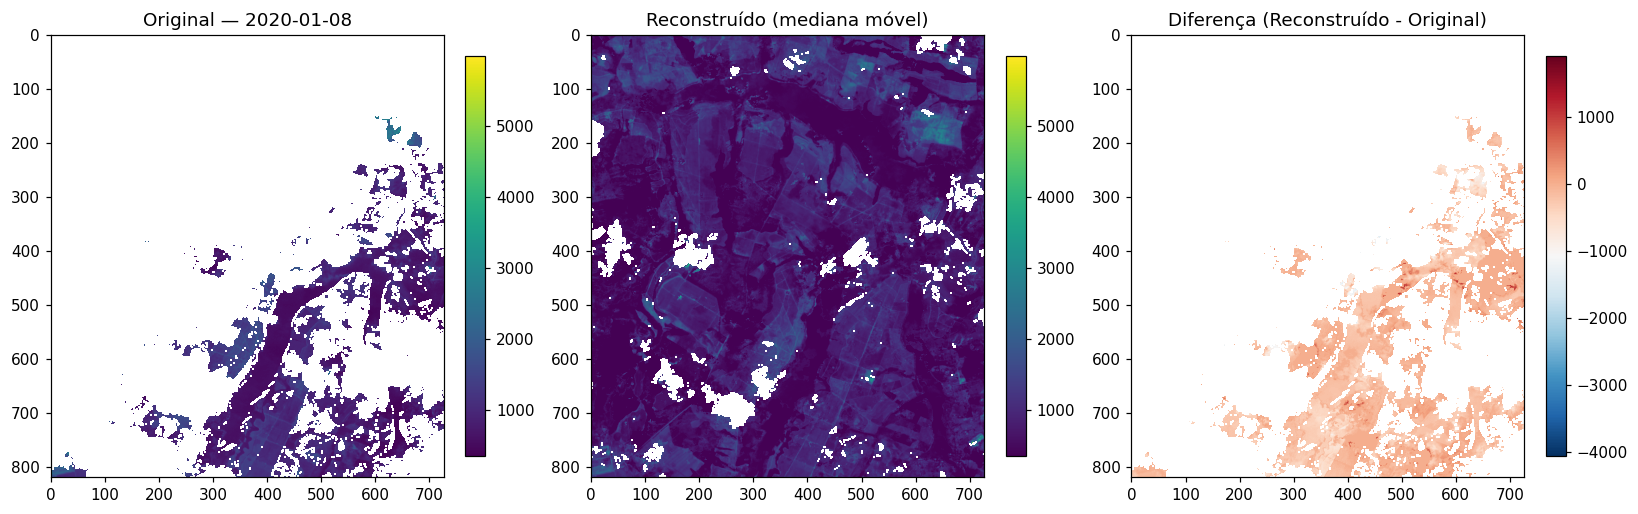

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

vmin = np.nanmin(stack[idx_data_exemplo])
vmax = np.nanmax(stack[idx_data_exemplo])

im0 = axes[0].imshow(stack[idx_data_exemplo], cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title(f"Original — {titulo_data}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(stack_reconstruido[idx_data_exemplo], cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Reconstruído (mediana móvel)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

diferenca = stack_reconstruido[idx_data_exemplo] - stack[idx_data_exemplo]
im2 = axes[2].imshow(diferenca, cmap="RdBu_r")
axes[2].set_title("Diferença (Reconstruído - Original)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparacao_original_vs_reconstruido_data.png")
plt.show()


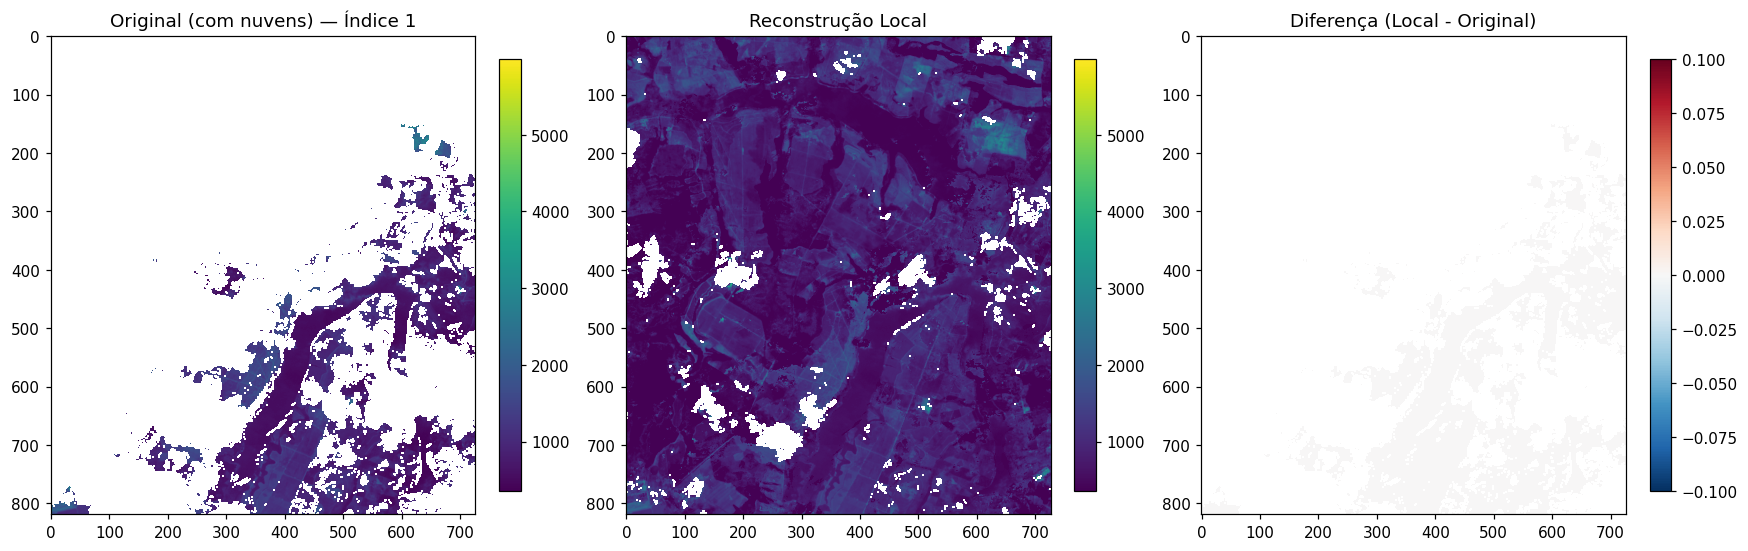

In [17]:
# Comparação cartográfica para a Reconstrução Local
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

vmin = np.nanmin(stack[idx_data_exemplo])
vmax = np.nanmax(stack[idx_data_exemplo])

# Imagem original
im0 = axes[0].imshow(stack[idx_data_exemplo], cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title(f"Original (com nuvens) — Índice {idx_data_exemplo}")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Reconstrução local
im1 = axes[1].imshow(stack_reconstruido_local[idx_data_exemplo], cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("Reconstrução Local")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Mapa de diferença local (prova visual de preservação perfeita)
diferenca_local = stack_reconstruido_local[idx_data_exemplo] - stack[idx_data_exemplo]
im2 = axes[2].imshow(diferenca_local, cmap="RdBu_r")
axes[2].set_title("Diferença (Local - Original)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "comparacao_espacial_metodo_local.png")
plt.show()


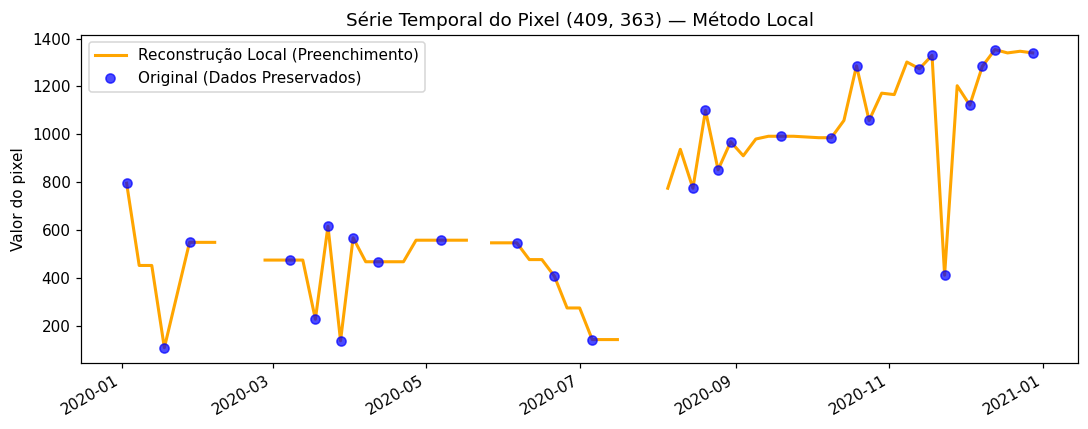

In [18]:
# Série temporal comparando original e reconstrução local
serie_local = stack_reconstruido_local[:, linha_pixel, coluna_pixel]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eixo_x, serie_local, "-", color="orange", linewidth=2, label="Reconstrução Local (Preenchimento)")
ax.plot(eixo_x, serie_original, "o", color="blue", alpha=0.7, label="Original (Dados Preservados)")
ax.set_title(f"Série Temporal do Pixel ({linha_pixel}, {coluna_pixel}) — Método Local")
ax.set_ylabel("Valor do pixel")
ax.legend()
if all(d is not None for d in datas):
    fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "serie_temporal_pixel_local.png")
plt.show()


## 7. Validação Quantitativa com Métricas SSIM e PSNR

Para verificar matematicamente a fidelidade da reconstrução, submetemos os dados a uma validação quantitativa por degradação sintética. 

Essa validação seleciona a imagem mais limpa da série como Ground Truth, corrompe artificialmente uma fração de seus pixels válidos para simular a contaminação por nuvens, aplica os métodos de reconstrução e avalia o resultado através do cálculo de:
*   **SSIM (Índice de Similaridade Estrutural):** Avalia a fidelidade de luminância, contraste e estrutura espacial na cena (varia de -1 a 1, onde 1 indica semelhança espacial perfeita).
*   **PSNR (Relação Sinal-Ruído de Pico):** Mede a intensidade do ruído inserido no sinal real da imagem, em decibéis (valores acima de 30 dB representam excelente qualidade de reconstrução física).



### Validação Quantitativa: Reconstrução Local / Cirúrgica


In [19]:
np.random.seed(26082002)

# 1. Recarrega a imagem de referência limpa
pct_nan_por_data = np.isnan(stack).mean(axis=(1, 2))
idx_ref = int(np.argmin(pct_nan_por_data))
img_ref = stack[idx_ref].copy()
data_str = datas[idx_ref].strftime('%Y-%m-%d') if datas[idx_ref] else f'Índice {idx_ref}'

# 2. Corrompe sinteticamente 10% dos pixels originalmente válidos
indices_validos = np.argwhere(~np.isnan(img_ref))
taxa_corrupcao = 0.15
n_corromper = int(taxa_corrupcao * len(indices_validos))
sel = np.random.choice(len(indices_validos), size=n_corromper, replace=False)
pixels_corrompidos = indices_validos[sel]

mascara_sintetica = np.zeros_like(img_ref, dtype=bool)
mascara_sintetica[pixels_corrompidos[:, 0], pixels_corrompidos[:, 1]] = True

img_corrompida = img_ref.copy()
img_corrompida[mascara_sintetica] = np.nan

# 3. Submete ao método de reconstrução local
stack_teste = stack.copy()
stack_teste[idx_ref] = img_corrompida
stack_teste_reconstruido = reconstrucao_mediana_movel_local(stack_teste, JANELA_TEMPORAL)

img_reconstruida = stack_teste_reconstruido[idx_ref]

# 4. Avalia as métricas exclusivamente onde ambos possuem valores numéricos válidos
mask_valid_eval = ~(np.isnan(img_ref) | np.isnan(img_reconstruida))
valid_original = img_ref[mask_valid_eval]
valid_cleaned = img_reconstruida[mask_valid_eval]

data_range = float(
    max(valid_original.max(), valid_cleaned.max())
    - min(valid_original.min(), valid_cleaned.min())
)
if data_range == 0:
    data_range = 1.0

# Criação das matrizes 2D livre de NaNs para avaliação espacial do SSIM
img_original_ssim = np.zeros_like(img_ref, dtype=np.float32)
img_cleaned_ssim = np.zeros_like(img_reconstruida, dtype=np.float32)

img_original_ssim[mask_valid_eval] = valid_original
img_cleaned_ssim[mask_valid_eval] = valid_cleaned

# Cálculo do SSIM e PSNR
ssim_val = structural_similarity(img_original_ssim, img_cleaned_ssim, data_range=data_range)
psnr_val = peak_signal_noise_ratio(valid_original, valid_cleaned, data_range=data_range)

print("=" * 60)
print(f"{'VALIDAÇÃO QUANTITATIVA - MÉTODO LOCAL':^60}")
print("=" * 60)
print(f"Imagem Referência: {data_str}")
print(f"Nuvem Sintética:   {100 * mascara_sintetica.mean():.1f}% da cena")
print("-" * 60)
print(f"SSIM:              {ssim_val:.4f} (Máximo ideal = 1.0)")
print(f"PSNR:              {psnr_val:.2f} dB")
print("=" * 60)


/tmp/ipykernel_203202/2693398398.py:59: RuntimeWarning: All-NaN slice encountered
  medianas_calculadas = np.nanmedian(dados_locais, axis=0)


           VALIDAÇÃO QUANTITATIVA - MÉTODO LOCAL            
Imagem Referência: 2020-04-02
Nuvem Sintética:   13.6% da cena
------------------------------------------------------------
SSIM:              0.9256 (Máximo ideal = 1.0)
PSNR:              35.52 dB


Aqui é feita um cálculo 1% a 50% de pixels corrompidos sintéticos

In [ ]:

data_range_fixo = float(np.nanmax(img_ref) - np.nanmin(img_ref))
if data_range_fixo == 0:
    data_range_fixo = 1.0

taxas_corrupcao = np.arange(0.01, 0.51, 0.01)  # 1% até 50%, passo de 1%
resultados = []

for taxa in taxas_corrupcao:
    np.random.seed(26082002)  # mesma seed em todos os testes

    indices_validos = np.argwhere(~np.isnan(img_ref))
    n_corromper = int(taxa * len(indices_validos))
    sel = np.random.choice(len(indices_validos), size=n_corromper, replace=False)
    pixels_corrompidos = indices_validos[sel]

    mascara_sintetica = np.zeros_like(img_ref, dtype=bool)
    mascara_sintetica[pixels_corrompidos[:, 0], pixels_corrompidos[:, 1]] = True

    img_corrompida = img_ref.copy()
    img_corrompida[mascara_sintetica] = np.nan

    stack_teste = stack.copy()
    stack_teste[idx_ref] = img_corrompida
    stack_teste_reconstruido = reconstrucao_mediana_movel_local(stack_teste, JANELA_TEMPORAL)

    img_reconstruida = stack_teste_reconstruido[idx_ref]

    # Avalia SSIM/PSNR apenas nos pixels efetivamente corrompidos e reconstruídos
    mask_avaliacao = mascara_sintetica & ~np.isnan(img_reconstruida)

    if mask_avaliacao.sum() == 0:
        continue

    valid_original = img_ref[mask_avaliacao]
    valid_cleaned = img_reconstruida[mask_avaliacao]

    img_original_ssim = np.zeros_like(img_ref, dtype=np.float32)
    img_cleaned_ssim = np.zeros_like(img_reconstruida, dtype=np.float32)
    img_original_ssim[mask_avaliacao] = valid_original
    img_cleaned_ssim[mask_avaliacao] = valid_cleaned

    ssim_val = structural_similarity(img_original_ssim, img_cleaned_ssim, data_range=data_range_fixo)
    psnr_val = peak_signal_noise_ratio(valid_original, valid_cleaned, data_range=data_range_fixo)

    resultados.append({
        "taxa_corrupcao_pct": round(taxa * 100, 1),
        "n_pixels_corrompidos": mascara_sintetica.sum(),
        "n_pixels_avaliados": mask_avaliacao.sum(),
        "ssim": ssim_val,
        "psnr_db": psnr_val,
    })

df_validacao_corrupcao = pd.DataFrame(resultados)
df_validacao_corrupcao

/tmp/ipykernel_203202/2693398398.py:59: RuntimeWarning: All-NaN slice encountered
  medianas_calculadas = np.nanmedian(dados_locais, axis=0)


,taxa_corrupcao_pct,n_pixels_corrompidos,n_pixels_avaliados,ssim,psnr_db
0,1.0,5415,5407,0.988927,27.150376
1,2.0,10831,10814,0.979140,27.074489
2,3.0,16247,16215,0.971284,27.149150
3,4.0,21663,21622,0.964401,27.193357
4,5.0,27078,27033,0.958451,27.250845
5,6.0,32494,32436,0.953236,27.258304
6,7.0,37910,37839,0.948711,27.252960
7,8.0,43326,43246,0.944782,27.251527
8,9.0,48741,48646,0.941344,27.275899
9,10.0,54157,54053,0.938100,27.271072


In [22]:
# Arredonda o SSIM para 4 casas e o PSNR para 2 casas
df_validacao_corrupcao["ssim"] = df_validacao_corrupcao["ssim"].round(4)
df_validacao_corrupcao["psnr_db"] = df_validacao_corrupcao["psnr_db"].round(2)

# Agora sim, faz a exportação desejada
df_validacao_corrupcao.to_csv("tabela_final_relatorio.csv", index=False)

In [ ]:
print(df_validacao_corrupcao.to_markdown(index=False, floatfmt=".4f"))

|   taxa_corrupcao_pct |   n_pixels_corrompidos |   n_pixels_avaliados |   ssim |   psnr_db |
|---------------------:|-----------------------:|---------------------:|-------:|----------:|
|               1.0000 |              5415.0000 |            5407.0000 | 0.9889 |   27.1500 |
|               2.0000 |             10831.0000 |           10814.0000 | 0.9791 |   27.0700 |
|               3.0000 |             16247.0000 |           16215.0000 | 0.9713 |   27.1500 |
|               4.0000 |             21663.0000 |           21622.0000 | 0.9644 |   27.1900 |
|               5.0000 |             27078.0000 |           27033.0000 | 0.9585 |   27.2500 |
|               6.0000 |             32494.0000 |           32436.0000 | 0.9532 |   27.2600 |
|               7.0000 |             37910.0000 |           37839.0000 | 0.9487 |   27.2500 |
|               8.0000 |             43326.0000 |           43246.0000 | 0.9448 |   27.2500 |
|               9.0000 |             48741.0000 |           